In [2]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [3]:
ds = load_dataset("lukebarousse/data_jobs")


README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [4]:
ds.keys()

dict_keys(['train'])

In [5]:
df = ds["train"].to_pandas()
df.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-nu

In [7]:
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [9]:
df["month"] = df["job_posted_date"].dt.month
df["named_month"] = df["job_posted_date"].dt.strftime("%B")

df[["month", "named_month"]].head(5)

,month,named_month
0,6,June
1,1,January
2,10,October
3,7,July
4,8,August


In [10]:
type(df["job_skills"][100])

str

In [11]:
def literal_eval(text):
  if text and type(text) == str:
    return ast.literal_eval(text)
  return text

In [12]:
df['job_skills'] = df["job_skills"].apply(literal_eval)

In [13]:
type(df["job_skills"][100])

list

In [14]:
df_usa = df[df["job_country"] == "United States"]
df_usa.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,month,named_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None,6,June
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",7,July
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,None,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '...",11,November
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,None,NaN,NaN,"Miracle Software Systems, Inc","[sql, python, java, sql server, gcp, bigquery,...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",3,March
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,None,NaN,NaN,"Radwell International, LLC","[sql, python, r, mongodb, mongodb, sql server,...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",4,April


In [15]:
top_jobs = df_usa["job_title_short"].value_counts().head(6).index.to_list()
top_jobs

['Data Analyst',
 'Data Scientist',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Analyst',
 'Senior Data Engineer']

In [16]:
df_top_jobs = df_usa[df_usa["job_title_short"].isin(top_jobs)]
df_top_jobs.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,month,named_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None,6,June
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",7,July
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,None,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '...",11,November
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,None,NaN,NaN,"Miracle Software Systems, Inc","[sql, python, java, sql server, gcp, bigquery,...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",3,March
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,None,NaN,NaN,"Radwell International, LLC","[sql, python, r, mongodb, mongodb, sql server,...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",4,April


In [17]:
total_postings = df_top_jobs.groupby("job_title_short").agg("size")
total_postings

,0
job_title_short,
Data Analyst,67816
Data Engineer,35080
Data Scientist,58830
Senior Data Analyst,11791
Senior Data Engineer,9289
Senior Data Scientist,12946


In [18]:
dict_post =total_postings.to_dict()
dict_post

{'Data Analyst': 67816,
 'Data Engineer': 35080,
 'Data Scientist': 58830,
 'Senior Data Analyst': 11791,
 'Senior Data Engineer': 9289,
 'Senior Data Scientist': 12946}

In [19]:
dict_post["Data Analyst"]

67816

In [20]:
def get_total_postings(title):
  return dict_post[title]

In [21]:
df_top_jobs["total_postings"] = df_top_jobs["job_title_short"].apply(get_total_postings)
df_top_jobs.sample(20, random_state=42)

/tmp/ipykernel_1873/4205113430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_jobs["total_postings"] = df_top_jobs["job_title_short"].apply(get_total_postings)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,month,named_month,total_postings
448315,Senior Data Engineer,Senior Data Engineer,"Flowery Branch, GA",via Dice,Contractor,False,"Florida, United States",2023-04-06 14:10:06,False,False,United States,hour,NaN,65.0,The Royak Group Inc.,"[sql, python, c#, sql server, azure, aws, airf...","{'analyst_tools': ['ssis'], 'cloud': ['azure',...",4,April,9289
711127,Data Scientist,Data Scientist,"Louisville, KY",via Indeed,Full-time,False,"Illinois, United States",2023-08-18 02:05:33,False,False,United States,None,NaN,NaN,Humana,"[sql, sas, sas, r, python, azure]","{'analyst_tools': ['sas'], 'cloud': ['azure'],...",8,August,58830
430751,Data Analyst,Data Analyst and Coordination Specialist (SY22...,"Boston, MA",via Indeed,Full-time,False,"New York, United States",2023-02-03 16:00:36,False,False,United States,None,NaN,NaN,Boston Public Schools,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['...",2,February,67816
719742,Data Analyst,Data Management and Analysis Manager,"Chicago, IL",via LinkedIn,Full-time,False,"Illinois, United States",2023-04-21 21:02:26,False,False,United States,None,NaN,NaN,Gads Hill Center,"[excel, word, tableau]","{'analyst_tools': ['excel', 'word', 'tableau']}",4,April,67816
206556,Data Engineer,Sr. Data Engineer,"Seattle, WA",via LinkedIn,Contractor,False,"Texas, United States",2023-03-31 22:09:11,False,False,United States,None,NaN,NaN,Insight Global,"[go, python, aws, azure, databricks, pyspark, ...","{'cloud': ['aws', 'azure', 'databricks'], 'lib...",3,March,35080
68302,Data Analyst,Retail System Data Analyst,"Schiller Park, IL",via BeBee,Full-time,False,"Illinois, United States",2023-05-25 06:01:39,False,False,United States,None,NaN,NaN,True Value,"[sql, excel, alteryx, power bi, flow]","{'analyst_tools': ['excel', 'alteryx', 'power ...",5,May,67816
613007,Data Analyst,Data Analyst,"McKinney, TX",via Adzuna,Full-time,False,"Texas, United States",2023-05-25 12:00:57,True,False,United States,None,NaN,NaN,Globe Life Inc.,"[r, python, tableau, excel]","{'analyst_tools': ['tableau', 'excel'], 'progr...",5,May,67816
614050,Data Scientist,Post Baccalaureate Fellow- Data Science,"Berkeley, CA",via DiversityJobs,Full-time,False,"California, United States",2023-02-22 12:02:40,False,False,United States,None,NaN,NaN,Lawrence Berkeley National Laboratory,"[python, jupyter, github]","{'libraries': ['jupyter'], 'other': ['github']...",2,February,58830
230490,Data Engineer,Data Engineer,"Thousand Oaks, CA",via BeBee,Full-time,False,"Florida, United States",2023-12-14 07:08:44,False,True,United States,None,NaN,NaN,CareerBuilder,"[sql, python, sql server, snowflake, oracle, t...","{'analyst_tools': ['tableau', 'power bi'], 'cl...",12,December,35080
763392,Data Analyst,Data Analyst (w2-requirement),"Ridgefield, NJ",via Indeed,Full-time,False,"New York, United States",2023-04-07 20:00:03,False,True,United States,None,NaN,NaN,Geopaq Logic,[sql],{'programming': ['sql']},4,April,67816


In [22]:
df_exploded = df_top_jobs.explode("job_skills")
df_exploded.sample(10, random_state=42)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,month,named_month,total_postings
170317,Data Engineer,Big Data Engineer,"Austin, TX",via LinkedIn,Contractor,False,"Illinois, United States",2023-12-15 15:07:37,False,False,United States,None,NaN,NaN,"VMC Soft Technologies, Inc",sql,"{'cloud': ['aws', 'snowflake'], 'libraries': [...",12,December,35080
575051,Data Engineer,Azure Data Engineer,"Birmingham, AL",via LinkedIn,Full-time,False,Georgia,2023-08-08 09:53:58,True,True,United States,None,NaN,NaN,CGI,databricks,"{'analyst_tools': ['ssis'], 'cloud': ['azure',...",8,August,35080
365138,Data Analyst,Data Analyst - remote!,Anywhere,via ZipRecruiter,Full-time,True,"Illinois, United States",2023-03-07 23:03:55,False,False,United States,None,NaN,NaN,Principal Financial Group,python,"{'analyst_tools': ['power bi', 'excel'], 'clou...",3,March,67816
442057,Senior Data Analyst,Senior Financial Data Analyst (Tax),Anywhere,via InHerSight,Full-time,True,"Illinois, United States",2023-05-15 16:01:27,False,True,United States,None,NaN,NaN,EquipmentShare,sql,"{'analyst_tools': ['excel'], 'other': ['chef']...",5,May,11791
26878,Data Analyst,Data Analyst III,"Carson City, NV",via BeBee,Full-time,False,"California, United States",2023-02-16 13:00:52,False,True,United States,None,NaN,NaN,Centene Corporation,excel,"{'analyst_tools': ['excel', 'power bi'], 'prog...",2,February,67816
462660,Data Engineer,Data Engineer (56664BR),Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-11-21 14:09:31,False,True,United States,None,NaN,NaN,Harvard Medical School,sql server,"{'cloud': ['aws', 'azure'], 'databases': ['sql...",11,November,35080
726878,Data Scientist,"Data Scientist, Mid with Security Clearance","Norfolk, VA",via LinkedIn,Full-time and Part-time,False,Georgia,2023-12-01 21:43:16,False,True,United States,None,NaN,NaN,ClearanceJobs,redshift,"{'cloud': ['aws', 'redshift', 'azure', 'databr...",12,December,58830
717759,Data Analyst,Junior Java Programmer /data analyst /Data sci...,"San Jose, CA",via IT JobServe,Full-time,False,"California, United States",2023-07-09 02:00:44,False,False,United States,None,NaN,NaN,SynergisticIT,spring,"{'analyst_tools': ['sas', 'tableau'], 'cloud':...",7,July,67816
90721,Data Analyst,Data Analyst (Telework),Anywhere,via Recruit.net,Full-time,True,"Texas, United States",2023-02-11 00:01:35,True,False,United States,None,NaN,NaN,Texas State Job Bank,outlook,"{'analyst_tools': ['spss', 'tableau', 'outlook...",2,February,67816
504877,Data Scientist,Data Scientist (AI/ML Expert and Implementatio...,"Pittsburgh, PA",via LinkedIn,Full-time,False,Georgia,2023-02-11 11:36:41,False,False,United States,None,NaN,NaN,Carmeuse,azure,"{'cloud': ['azure'], 'libraries': ['jupyter'],...",2,February,58830


In [23]:
df_reduced = df_exploded[["job_title_short", "job_skills", "total_postings"]]
df_reduced.head()

,job_title_short,job_skills,total_postings
0,Senior Data Engineer,None,9289
3,Data Engineer,python,35080
3,Data Engineer,c++,35080
3,Data Engineer,java,35080
3,Data Engineer,matlab,35080


In [24]:
table = (
    df_exploded
    .groupby(["job_title_short", "job_skills"])
    .size()
    .reset_index(name="skill_count")
)
table.head()

,job_title_short,job_skills,skill_count
0,Data Analyst,airflow,387
1,Data Analyst,airtable,36
2,Data Analyst,alteryx,2045
3,Data Analyst,angular,129
4,Data Analyst,ansible,48


In [25]:
df_joined = df_reduced.merge(
    table,
    on=["job_title_short", "job_skills"],
    how="left"
)
df_joined = df_joined.dropna()

df_joined

,job_title_short,job_skills,total_postings,skill_count
1,Data Engineer,python,35080,22762.0
2,Data Engineer,c++,35080,1136.0
3,Data Engineer,java,35080,8361.0
4,Data Engineer,matlab,35080,319.0
5,Data Engineer,aws,35080,15018.0
...,...,...,...,...
1030436,Data Scientist,matlab,58830,3269.0
1030437,Data Scientist,r,58830,26022.0
1030439,Data Analyst,sql,67816,34452.0
1030440,Data Analyst,python,67816,18382.0


In [26]:
df_joined["skill_count_percentage"] = df_joined["skill_count"] / df_joined["total_postings"] * 100
df_joined

,job_title_short,job_skills,total_postings,skill_count,skill_count_percentage
1,Data Engineer,python,35080,22762.0,64.885975
2,Data Engineer,c++,35080,1136.0,3.238312
3,Data Engineer,java,35080,8361.0,23.834094
4,Data Engineer,matlab,35080,319.0,0.909350
5,Data Engineer,aws,35080,15018.0,42.810718
...,...,...,...,...,...
1030436,Data Scientist,matlab,58830,3269.0,5.556689
1030437,Data Scientist,r,58830,26022.0,44.232534
1030439,Data Analyst,sql,67816,34452.0,50.802171
1030440,Data Analyst,python,67816,18382.0,27.105698


In [27]:
df_joined.drop_duplicates(inplace=True)

In [28]:
df_joined.sort_values(by=["job_title_short", "skill_count_percentage"], ascending=[True, False], inplace=True)
df_joined

,job_title_short,job_skills,total_postings,skill_count,skill_count_percentage
339,Data Analyst,sql,67816,34452.0,50.802171
149,Data Analyst,excel,67816,27519.0,40.578919
204,Data Analyst,tableau,67816,19311.0,28.475581
201,Data Analyst,python,67816,18382.0,27.105698
152,Data Analyst,sas,67816,13200.0,19.464433
...,...,...,...,...,...
514743,Senior Data Scientist,groovy,12946,1.0,0.007724
615822,Senior Data Scientist,vb.net,12946,1.0,0.007724
636623,Senior Data Scientist,drupal,12946,1.0,0.007724
679111,Senior Data Scientist,mariadb,12946,1.0,0.007724


<Axes: xlabel='job_skills'>

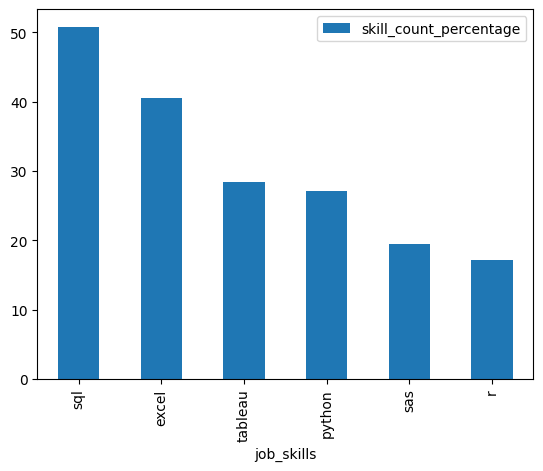

In [29]:
df_joined[df_joined["job_title_short"] == "Data Analyst"].head(6).plot(kind="bar",x="job_skills", y="skill_count_percentage")

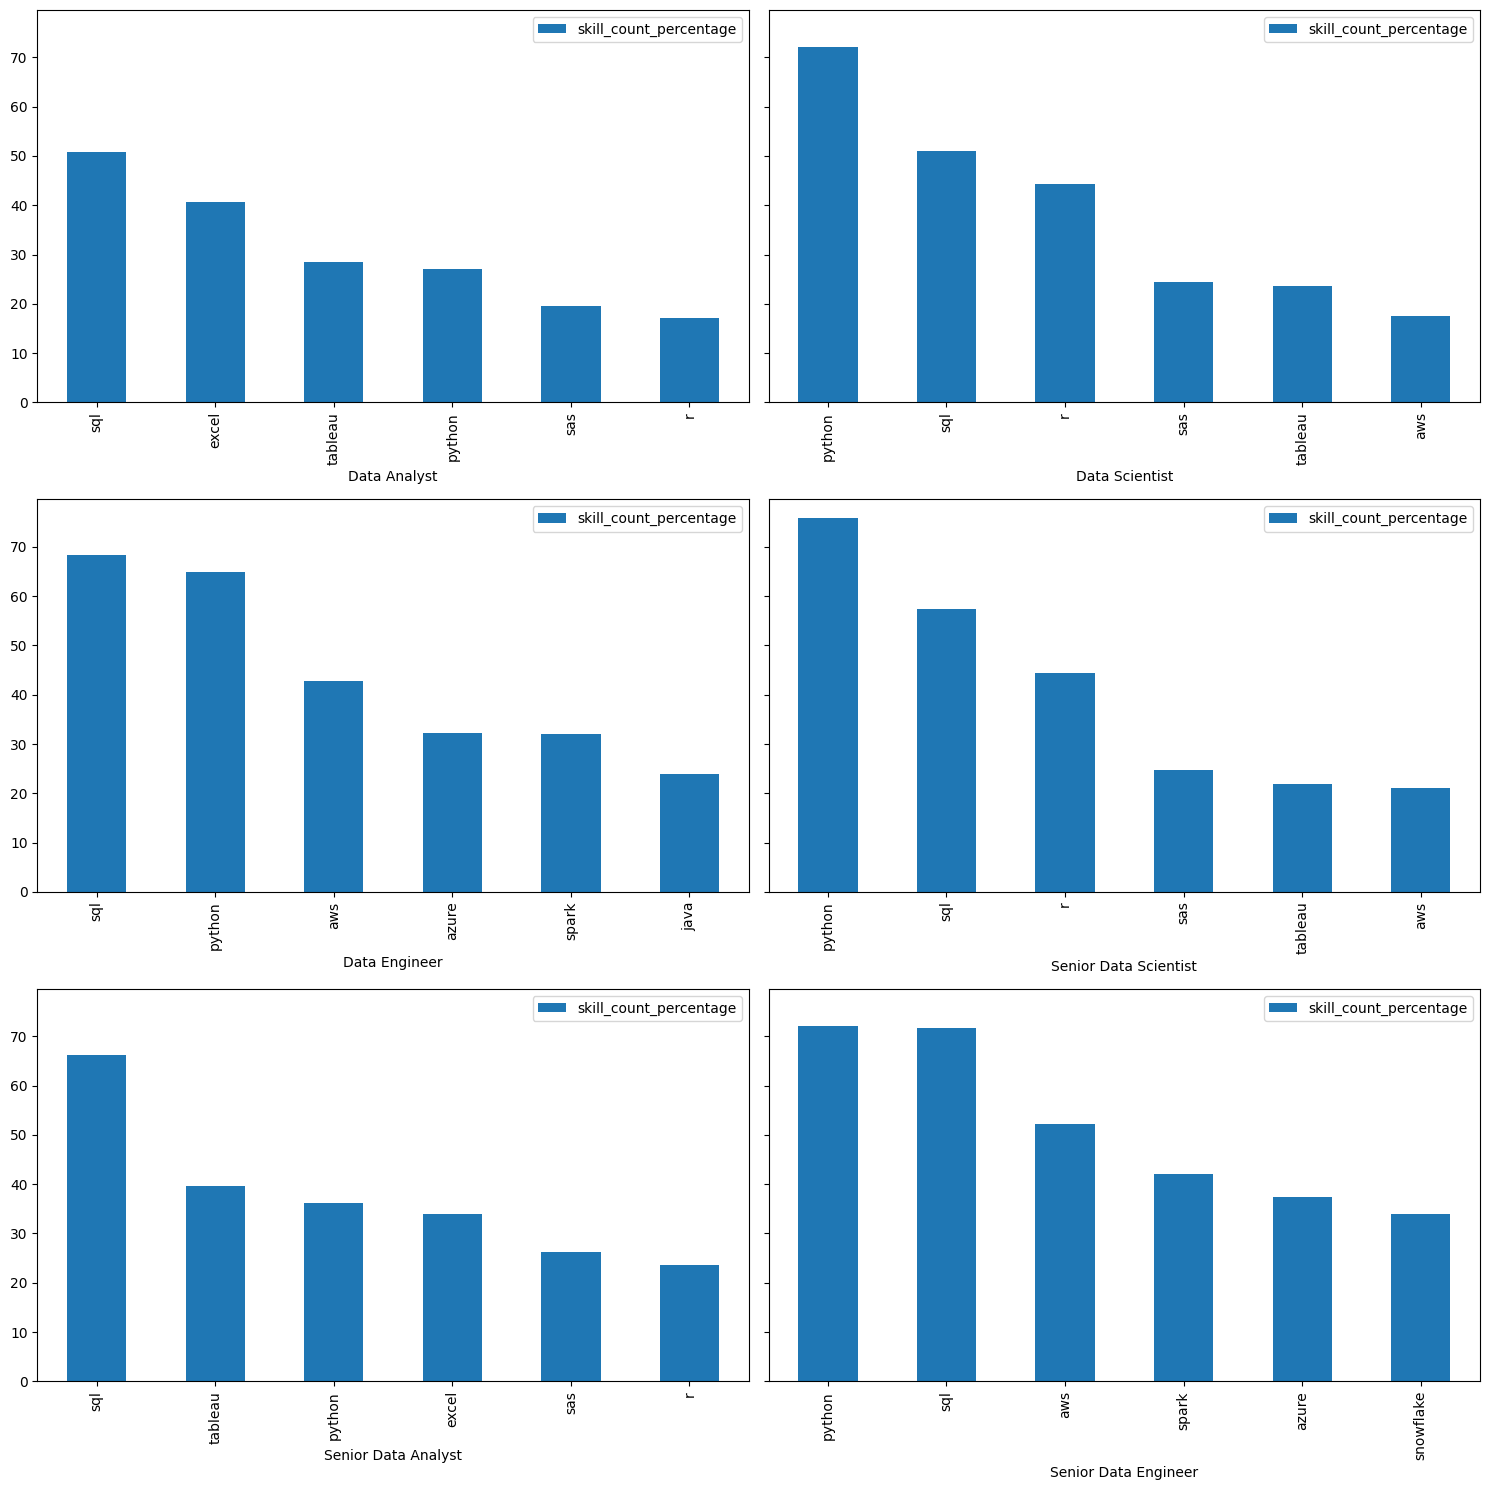

In [32]:
fig, ax = plt.subplots(int(len(top_jobs)/2), 2, figsize=(15,15), sharey=True)

i=0
j=0
for job in top_jobs:
  df_joined[df_joined["job_title_short"] == job].head(6).plot(kind="bar",x="job_skills", y="skill_count_percentage", ax=ax[i,j], xlabel = job)
  j+=1
  if j == 2:
    j=0
    i+=1

plt.tight_layout()
